In [133]:
# Import the necessary packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [134]:
# Import the dataset using pandas read_csv
df = pd.read_csv("house_sales.csv")

# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Ensure head displays all columns
pd.set_option('display.max_columns', None)

# Display the top 5 rows
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,2014-10-13,"221,900.00",3.00,1.00,"1,180.00","5,650.00",1.00,0,0,3,7,1180,0,1955,0,98178,47.51,-122.26,1340,5650
1,6414100192,2014-12-09,"538,000.00",3.00,2.25,"2,570.00","7,242.00",2.00,0,0,3,7,2170,400,1951,1991,98125,47.72,-122.32,1690,7639
2,5631500400,2015-02-25,"180,000.00",2.00,1.00,770.00,"10,000.00",1.00,0,0,3,6,770,0,1933,0,98028,47.74,-122.23,2720,8062
3,2487200875,2014-12-09,"604,000.00",4.00,3.00,"1,960.00","5,000.00",1.00,0,0,5,7,1050,910,1965,0,98136,47.52,-122.39,1360,5000
4,1954400510,2015-02-18,"510,000.00",3.00,2.00,"1,680.00","8,080.00",1.00,0,0,3,8,1680,0,1987,0,98074,47.62,-122.05,1800,7503


In [135]:
# Calculate descriptive statistics including Skewness
stats = df.describe().T
stats['skew'] = df.select_dtypes(include=[np.number]).skew()

print("--- Descriptive Statistics with Skewness ---")
display(stats[['mean', 'std', 'min', '50%', 'max', 'skew']])

--- Descriptive Statistics with Skewness ---


,mean,std,min,50%,max,skew
id,"4,580,301,520.86","2,876,565,571.31","1,000,102.00","3,904,930,410.00","9,900,000,190.00",0.24
date,2014-10-29 04:38:01.959931648,NaN,2014-05-02 00:00:00,2014-10-16 00:00:00,2015-05-27 00:00:00,NaN
price,"540,088.14","367,127.20","75,000.00","450,000.00","7,700,000.00",4.02
bedrooms,3.37,0.93,0.00,3.00,33.00,2.02
bathrooms,2.11,0.77,0.00,2.25,8.00,0.50
sqft_living,"2,081.07",915.04,290.00,"1,920.00","12,050.00",1.39
sqft_lot,"15,179.82","41,486.17",520.00,"7,620.00","1,651,359.00",12.88
floors,1.49,0.54,1.00,1.50,3.50,0.62
waterfront,0.01,0.09,0.00,0.00,1.00,11.39
view,0.23,0.77,0.00,0.00,4.00,3.40


In [136]:
# Display the shape of the dataframe
original_shape = df.shape
print(original_shape)

# Display count by data type
df.dtypes.value_counts()

(21613, 21)


int64             12
float64            8
datetime64[ns]     1
Name: count, dtype: int64

In [137]:
# Display column number, column name, non-null count, and data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   id             21613 non-null  int64         
 1   date           21613 non-null  datetime64[ns]
 2   price          21613 non-null  float64       
 3   bedrooms       20479 non-null  float64       
 4   bathrooms      20545 non-null  float64       
 5   sqft_living    20503 non-null  float64       
 6   sqft_lot       20569 non-null  float64       
 7   floors         21613 non-null  float64       
 8   waterfront     21613 non-null  int64         
 9   view           21613 non-null  int64         
 10  condition      21613 non-null  int64         
 11  grade          21613 non-null  int64         
 12  sqft_above     21613 non-null  int64         
 13  sqft_basement  21613 non-null  int64         
 14  yr_built       21613 non-null  int64         
 15  yr_renovated   2161

In [138]:
# Display dimensions with NA values
null_counts = df.isna().sum()
null_counts[null_counts > 0]

bedrooms       1134
bathrooms      1068
sqft_living    1110
sqft_lot       1044
dtype: int64

In [139]:
# Impute sq_ft living for all values by adding sqft_above and sqft_basement
df['sqft_living'] = df['sqft_above'] + df['sqft_basement']
# Check NA values
assert (df['sqft_living'] - (df['sqft_above'] + df['sqft_basement'])).sum() == 0
print("sqft_living fully reconstructed and validated.")
print(df[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']].isna().sum())

sqft_living fully reconstructed and validated.
bedrooms       1134
bathrooms      1068
sqft_living       0
sqft_lot       1044
dtype: int64


In [140]:
# Impute missing values from sqft_lot by zip code median
zip_lot_medians = df.groupby('zipcode')['sqft_lot'].transform('median')
df['sqft_lot'] = df['sqft_lot'].fillna(zip_lot_medians)
# Check NA values
print(df[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']].isna().sum())

bedrooms       1134
bathrooms      1068
sqft_living       0
sqft_lot          0
dtype: int64


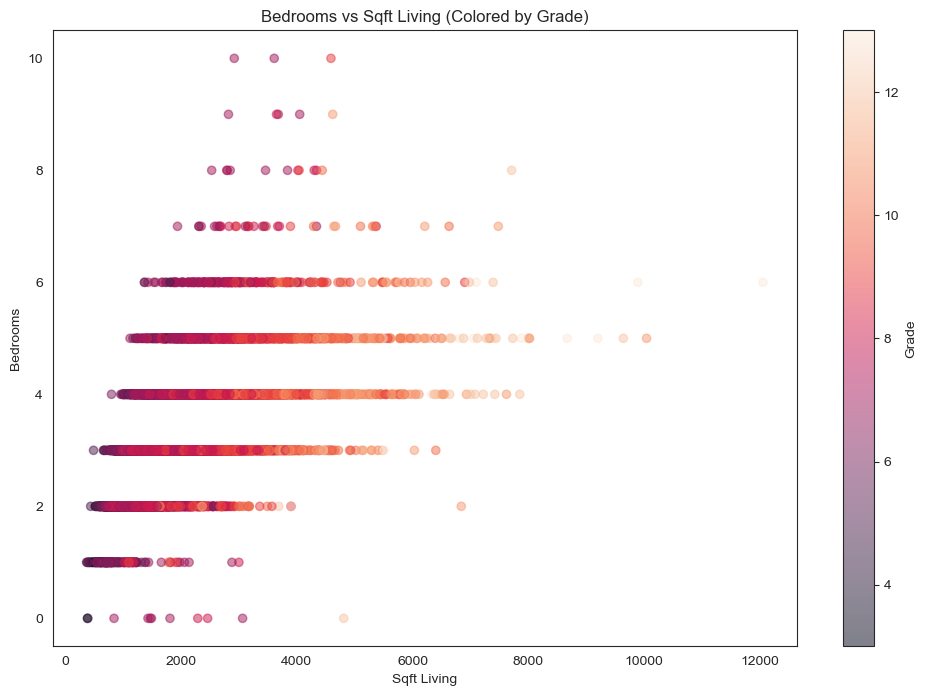

In [141]:
# Plot to look at the relationship between bedrooms, sqft_living, and grade
df_filtered = df[df['bedrooms'] < 30]

x = df_filtered['sqft_living']
y = df_filtered['bedrooms']
color = df_filtered['grade']

plt.figure(figsize=(12, 8))
plt.scatter(x, y, c = color, alpha = 0.5)
plt.colorbar(label='Grade')
plt.xlabel('Sqft Living')
plt.ylabel('Bedrooms')
plt.title('Bedrooms vs Sqft Living (Colored by Grade)')
plt.show()

In [142]:
# Identify the outlier (33 bedrooms) and replace with the median for its grade
outlier_grade = df.loc[df['bedrooms'] == 33, 'grade'].iloc[0]
grade_median = df[df['grade'] == outlier_grade]['bedrooms'].median()
df.loc[df['bedrooms'] == 33, 'bedrooms'] = grade_median

# Turn bed and bath zeroes into nulls for imputation
df.loc[df['bedrooms'] == 0, 'bedrooms'] = np.nan
df.loc[df['bathrooms'] == 0, 'bathrooms'] = np.nan

In [143]:
# Impute missing bedroom values from median sqft_living per bedrooms and grade

# Primary strategy - group by grade, median sqft_per_bed
df['sqft_per_bed'] = df['sqft_living'] / df['bedrooms']
grade_bed_median = df.groupby('grade')['sqft_per_bed'].transform('median')

# Backup strategy - global bed median if primary does not work (One grade 1 example)
global_bed_median = (df['sqft_living'] / df['bedrooms']).median()
imputed_beds = df['sqft_living'] / grade_bed_median.fillna(global_bed_median)
df['bedrooms'] = df['bedrooms'].fillna(imputed_beds).round().astype(int)

df = df.drop('sqft_per_bed', axis=1)

print(df[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']].isna().sum())

bedrooms          0
bathrooms      1076
sqft_living       0
sqft_lot          0
dtype: int64


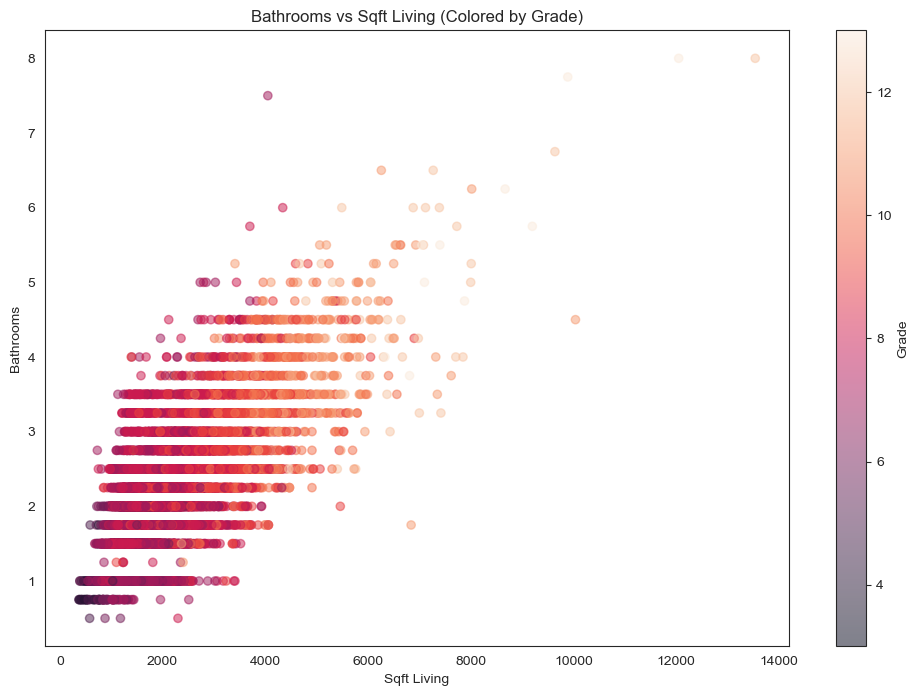

In [144]:
# Plot to look at the relationship between bathrooms, sqft_living, and grade
x = df['sqft_living']
y = df['bathrooms']
color = df['grade']

plt.figure(figsize=(12, 8))
plt.scatter(x, y, c = color, alpha = 0.5)
plt.colorbar(label='Grade')
plt.xlabel('Sqft Living')
plt.ylabel('Bathrooms')
plt.title('Bathrooms vs Sqft Living (Colored by Grade)')
plt.show()

In [145]:
# Calculate median bathrooms per bedroom count and map to missing values

# Primary strategy - group by grade, median sqft_per_bath
df['sqft_per_bath'] = df['sqft_living'] / df['bathrooms']
grade_bath_median = df.groupby('grade')['sqft_per_bath'].transform('median')

# Backup strategy - global bath median if primary does not work (One grade 1 example)
global_bath_median = (df['sqft_living'] / df['bathrooms']).median()
imputed_baths = df['sqft_living'] / grade_bath_median.fillna(global_bath_median)
df['bathrooms'] = df['bathrooms'].fillna(imputed_baths)

df = df.drop('sqft_per_bath', axis=1)

# Round bathrooms to a quarter point to match all data
df['bathrooms'] = (df['bathrooms'] * 4).round() / 4

# Check NA values
print(df[['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot']].isna().sum())

bedrooms       0
bathrooms      0
sqft_living    0
sqft_lot       0
dtype: int64


In [146]:
# Check summary metrics after imputing missing values
pd.set_option('display.float_format', '{:,.2f}'.format)
df.describe()

view_counts = df['view'].value_counts().sort_index()
print(view_counts)

view
0    19489
1      332
2      963
3      510
4      319
Name: count, dtype: int64


# The readme says that view should be binary - how should we handle this?

In [147]:
### Commented out so we don't accidentally overwrite a file if we don't mean to.

#df.to_csv('../Vis/cleaned_house_sales_with_outliers.csv', index=False)
#print("File saved successfully to the Vis folder!")

In [148]:
# Check for extreme outliers 3 times the IQR above or below the third or first quartiles.
for col in df.columns:
    # Calculate the outliers
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3.0 * iqr
    upper_bound = q3 + 3.0 * iqr
    # Count the outliers by column
    extreme_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    if len(extreme_outliers) > 0:
        print(f"Number of {col} outliers: {len(extreme_outliers)}")

df.describe()


Number of price outliers: 420
Number of bedrooms outliers: 23
Number of bathrooms outliers: 19
Number of sqft_living outliers: 74
Number of sqft_lot outliers: 1765
Number of waterfront outliers: 163
Number of view outliers: 2124
Number of grade outliers: 107
Number of sqft_above outliers: 60
Number of sqft_basement outliers: 29
Number of yr_renovated outliers: 914
Number of long outliers: 17
Number of sqft_living15 outliers: 23
Number of sqft_lot15 outliers: 1613


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,"21,613.00",21613,"21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00","21,613.00"
mean,"4,580,301,520.86",2014-10-29 04:38:01.959931648,"540,088.14",3.38,2.11,"2,079.90","14,853.75",1.49,0.01,0.23,3.41,7.66,"1,788.39",291.51,"1,971.01",84.40,"98,077.94",47.56,-122.21,"1,986.55","12,768.46"
min,"1,000,102.00",2014-05-02 00:00:00,"75,000.00",1.00,0.25,290.00,520.00,1.00,0.00,0.00,1.00,1.00,290.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00
25%,"2,123,049,194.00",2014-07-22 00:00:00,"321,950.00",3.00,1.50,"1,427.00","5,080.00",1.00,0.00,0.00,3.00,7.00,"1,190.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,490.00","5,100.00"
50%,"3,904,930,410.00",2014-10-16 00:00:00,"450,000.00",3.00,2.25,"1,910.00","7,663.00",1.50,0.00,0.00,3.00,7.00,"1,560.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,840.00","7,620.00"
75%,"7,308,900,445.00",2015-02-17 00:00:00,"645,000.00",4.00,2.50,"2,550.00","10,500.00",2.00,0.00,0.00,4.00,8.00,"2,210.00",560.00,"1,997.00",0.00,"98,118.00",47.68,-122.12,"2,360.00","10,083.00"
max,"9,900,000,190.00",2015-05-27 00:00:00,"7,700,000.00",11.00,8.00,"13,540.00","1,651,359.00",3.50,1.00,4.00,5.00,13.00,"9,410.00","4,820.00","2,015.00","2,015.00","98,199.00",47.78,-121.31,"6,210.00","871,200.00"
std,"2,876,565,571.31",NaN,"367,127.20",0.91,0.77,918.44,"40,511.67",0.54,0.09,0.77,0.65,1.18,828.09,442.58,29.37,401.68,53.51,0.14,0.14,685.39,"27,304.18"


We will not be removing bathrooms, view, or waterfront, these are valuable pieces of information that affects the price, outliers should not be unfairly penalized.

Year_renovated is also valuable information that should not be removed, if a house was renovated a long time ago its likely that is accurate and can affect the price.

It doesn't make sense to remove either of the sqft_living15 or sqft_lot15 metrics, those homes should not be penalized for a neighbor that is skewing that metric.

Latitude outliers don't make sense to remove, those are not true outliers.

There is likely significant overlap between sqft_living, sqft_above, and sqft_basement, but we will still remove all extreme outliers, although this is likely redundant. 

Sqft_lot is the last large count outlier, these are huge lots that are real and that does affect the value. Rather than removing these values as outliers, I recommend we log this variable in our visualization and analysis, which will effectively normalize these values.

In [149]:
# Check for extreme outliers 3 times the IQR above or below the third or first quartiles.
cols_to_filter = ['price', 'bedrooms', 'sqft_living', 'grade', 'sqft_above', 'sqft_basement']
# Make not of indices to drop
to_drop_indices = []

for col in cols_to_filter:
    # Calculate the outliers
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3.0 * iqr
    upper_bound = q3 + 3.0 * iqr
    # Grab the indices to drop
    extreme_outliers = df[(df[col] > upper_bound) | (df[col] < lower_bound)].index
    to_drop_indices.extend(extreme_outliers)
# Drop the outlier indices
df_no_outliers = df.drop(index=list(set(to_drop_indices)))
# See the number of rows to drop
print("The number of rows dropped since the original dataframe: " + str(original_shape[0] - df_no_outliers.shape[0]))
percentage_dropped = round(((1 - (df_no_outliers.shape[0] / original_shape[0])) * 100), 2)
print(f"The percentage of rows dropped since the original dataframe: {percentage_dropped}%")
df_no_outliers.describe()

The number of rows dropped since the original dataframe: 517
The percentage of rows dropped since the original dataframe: 2.39%


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,"21,096.00",21096,"21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00"
mean,"4,591,852,648.99",2014-10-29 05:45:35.836177408,"503,173.98",3.35,2.08,"2,017.88","14,406.88",1.49,0.00,0.20,3.41,7.59,"1,739.88",278.00,"1,970.87",79.94,"98,078.38",47.56,-122.21,"1,952.83","12,487.42"
min,"1,000,102.00",2014-05-02 00:00:00,"78,000.00",1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,4.00,370.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00
25%,"2,125,319,771.00",2014-07-22 00:00:00,"319,990.00",3.00,1.50,"1,410.00","5,040.00",1.00,0.00,0.00,3.00,7.00,"1,180.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,480.00","5,080.00"
50%,"3,905,005,275.00",2014-10-16 00:00:00,"445,000.00",3.00,2.25,"1,890.00","7,600.00",1.00,0.00,0.00,3.00,7.00,"1,540.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,820.00","7,560.00"
75%,"7,334,500,097.50",2015-02-17 00:00:00,"625,000.00",4.00,2.50,"2,500.00","10,306.50",2.00,0.00,0.00,4.00,8.00,"2,157.00",540.00,"1,996.00",0.00,"98,118.00",47.68,-122.12,"2,320.00","9,975.00"
max,"9,900,000,190.00",2015-05-27 00:00:00,"1,612,500.00",7.00,5.75,"5,860.00","1,651,359.00",3.50,1.00,4.00,5.00,11.00,"5,250.00","2,220.00","2,015.00","2,015.00","98,199.00",47.78,-121.31,"5,790.00","871,200.00"
std,"2,878,046,900.87",NaN,"253,387.11",0.89,0.72,809.70,"38,819.07",0.54,0.07,0.70,0.65,1.09,750.75,419.40,29.29,391.35,53.41,0.14,0.14,643.59,"26,353.99"


In [150]:

for col in df_no_outliers.columns:
    # Use the original date frame to calculate the outliers, otherwise we run into a problem where more outliers keep appearing.
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 3.0 * iqr
    upper_bound = q3 + 3.0 * iqr
    # Count the outliers by column
    extreme_outliers = df_no_outliers[(df_no_outliers[col] < lower_bound) | (df_no_outliers[col] > upper_bound)]
    if len(extreme_outliers) > 0:
        print(f"Number of {col} outliers: {len(extreme_outliers)}")

df_no_outliers.describe()

Number of bathrooms outliers: 1
Number of sqft_lot outliers: 1658
Number of waterfront outliers: 91
Number of view outliers: 1849
Number of yr_renovated outliers: 845
Number of long outliers: 17
Number of sqft_living15 outliers: 8
Number of sqft_lot15 outliers: 1517


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,"21,096.00",21096,"21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00"
mean,"4,591,852,648.99",2014-10-29 05:45:35.836177408,"503,173.98",3.35,2.08,"2,017.88","14,406.88",1.49,0.00,0.20,3.41,7.59,"1,739.88",278.00,"1,970.87",79.94,"98,078.38",47.56,-122.21,"1,952.83","12,487.42"
min,"1,000,102.00",2014-05-02 00:00:00,"78,000.00",1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,4.00,370.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00
25%,"2,125,319,771.00",2014-07-22 00:00:00,"319,990.00",3.00,1.50,"1,410.00","5,040.00",1.00,0.00,0.00,3.00,7.00,"1,180.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,480.00","5,080.00"
50%,"3,905,005,275.00",2014-10-16 00:00:00,"445,000.00",3.00,2.25,"1,890.00","7,600.00",1.00,0.00,0.00,3.00,7.00,"1,540.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,820.00","7,560.00"
75%,"7,334,500,097.50",2015-02-17 00:00:00,"625,000.00",4.00,2.50,"2,500.00","10,306.50",2.00,0.00,0.00,4.00,8.00,"2,157.00",540.00,"1,996.00",0.00,"98,118.00",47.68,-122.12,"2,320.00","9,975.00"
max,"9,900,000,190.00",2015-05-27 00:00:00,"1,612,500.00",7.00,5.75,"5,860.00","1,651,359.00",3.50,1.00,4.00,5.00,11.00,"5,250.00","2,220.00","2,015.00","2,015.00","98,199.00",47.78,-121.31,"5,790.00","871,200.00"
std,"2,878,046,900.87",NaN,"253,387.11",0.89,0.72,809.70,"38,819.07",0.54,0.07,0.70,0.65,1.09,750.75,419.40,29.29,391.35,53.41,0.14,0.14,643.59,"26,353.99"


Like I mentioned earlier, bathrooms is not getting touched, sqft_lot we will transform with a log, waterfront, view, yr_renovated, and long are not valid outliers, and sqft_living15/sqft_lot15 should not penalize that individual row.

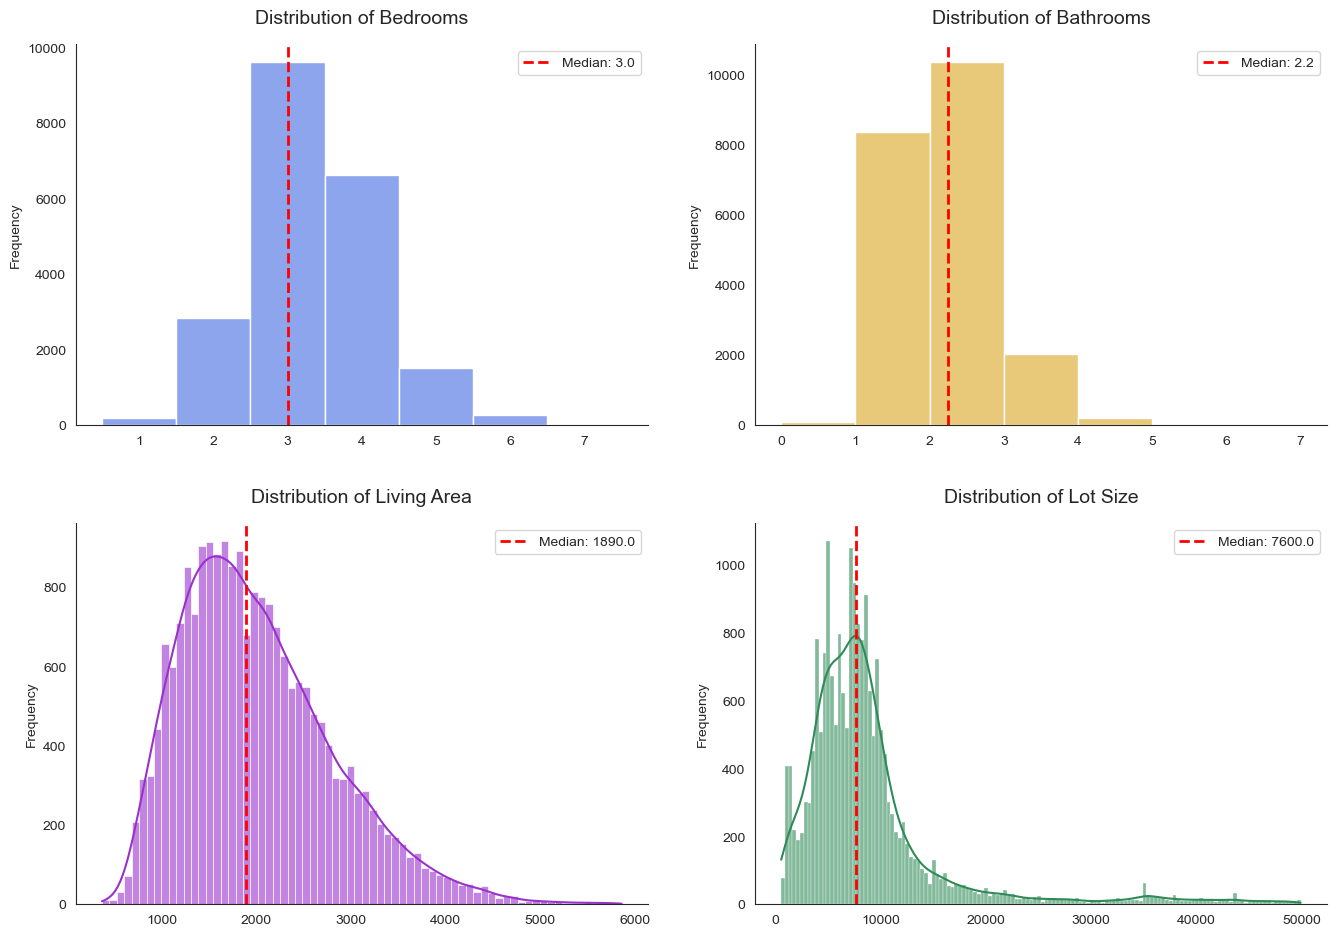

In [151]:
cfg = [
    ('bedrooms', 'Bedrooms', 'royalblue', 10),
    ('bathrooms', 'Bathrooms', 'goldenrod', 6),
    ('sqft_living', 'Living Area', 'darkorchid', 6000),
    ('sqft_lot', 'Lot Size', 'seagreen', 50000)
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_style("white") # Clean white background

for ax, (col, title, color, limit) in zip(axes.flatten(), cfg):
    # Filter data for visualization only (prevents outliers from squishing the plot)
    plot_data = df_no_outliers[df_no_outliers[col] <= limit][col] if limit else df_no_outliers[col]
    
    # Use discrete=True for counts to center bars on integers
    is_discrete = col in ['bedrooms', 'bathrooms']
    
    sns.histplot(plot_data, kde=not is_discrete, ax=ax, color=color, 
                 alpha=0.6, discrete=is_discrete, edgecolor='white')
    
    # Add Median Line
    median_val = df_no_outliers[col].median()
    ax.axvline(median_val, color='red', ls='--', lw=2, label=f'Median: {median_val:.1f}')
    
    # Professional Formatting
    ax.set_title(f'Distribution of {title}', fontsize=14, pad=15)
    ax.set_xlabel(None)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.legend(frameon=True)
    sns.despine() # Removes the top and right borders for a modern look

plt.tight_layout(pad=3.0)
plt.show()


In [152]:
### Feature construction

# Construct house age from date and year built
df_no_outliers['house_age'] = df_no_outliers['date'].dt.year - df_no_outliers['yr_built']
df_no_outliers['house_age'] = df_no_outliers['house_age'].clip(lower=0)
# Construct an indicator variable for if the house has ever been renovated.
df_no_outliers['renovated_bool'] = [1 if x > 0 else 0 for x in df_no_outliers['yr_renovated']]

# Create a few logged variables for visualization and analysis
df_no_outliers['log_price'] = np.log(df_no_outliers['price']).round(4)
df_no_outliers['log_sqft_lot'] = np.log(df_no_outliers['sqft_lot']).round(4)
df_no_outliers['log_sqft_lot15'] = np.log(df_no_outliers['sqft_lot15']).round(4)

# Living to lot ratio
df_no_outliers['living_lot_ratio'] = (df_no_outliers['sqft_living'] / df_no_outliers['sqft_lot']).round(3)

# Month of sale (that may influence the price)
df_no_outliers['sale_month'] = df_no_outliers['date'].dt.month

# Grade /condition groups - lets visualize these in the next step to see if these are meaningful or if we can improve them
df_no_outliers['grade_level'] = pd.cut(df_no_outliers['grade'], bins=[0, 6, 9, 13], labels=['Low', 'Mid', 'High'])
df_no_outliers['condition_level'] = pd.cut(df_no_outliers['condition'], bins = [0, 2, 3, 5], 
                                          labels = ['Poor', 'Average', 'Good'])

df_no_outliers.describe()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,house_age,renovated_bool,log_price,log_sqft_lot,log_sqft_lot15,living_lot_ratio,sale_month
count,"21,096.00",21096,"21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00","21,096.00"
mean,"4,591,852,648.99",2014-10-29 05:45:35.836177408,"503,173.98",3.35,2.08,"2,017.88","14,406.88",1.49,0.00,0.20,3.41,7.59,"1,739.88",278.00,"1,970.87",79.94,"98,078.38",47.56,-122.21,"1,952.83","12,487.42",43.45,0.04,13.01,8.97,8.95,0.32,6.58
min,"1,000,102.00",2014-05-02 00:00:00,"78,000.00",1.00,0.50,370.00,520.00,1.00,0.00,0.00,1.00,4.00,370.00,0.00,"1,900.00",0.00,"98,001.00",47.16,-122.52,399.00,651.00,0.00,0.00,11.26,6.25,6.48,0.00,1.00
25%,"2,125,319,771.00",2014-07-22 00:00:00,"319,990.00",3.00,1.50,"1,410.00","5,040.00",1.00,0.00,0.00,3.00,7.00,"1,180.00",0.00,"1,951.00",0.00,"98,033.00",47.47,-122.33,"1,480.00","5,080.00",18.00,0.00,12.68,8.53,8.53,0.16,4.00
50%,"3,905,005,275.00",2014-10-16 00:00:00,"445,000.00",3.00,2.25,"1,890.00","7,600.00",1.00,0.00,0.00,3.00,7.00,"1,540.00",0.00,"1,975.00",0.00,"98,065.00",47.57,-122.23,"1,820.00","7,560.00",40.00,0.00,13.01,8.94,8.93,0.25,6.00
75%,"7,334,500,097.50",2015-02-17 00:00:00,"625,000.00",4.00,2.50,"2,500.00","10,306.50",2.00,0.00,0.00,4.00,8.00,"2,157.00",540.00,"1,996.00",0.00,"98,118.00",47.68,-122.12,"2,320.00","9,975.00",63.00,0.00,13.35,9.24,9.21,0.40,9.00
max,"9,900,000,190.00",2015-05-27 00:00:00,"1,612,500.00",7.00,5.75,"5,860.00","1,651,359.00",3.50,1.00,4.00,5.00,11.00,"5,250.00","2,220.00","2,015.00","2,015.00","98,199.00",47.78,-121.31,"5,790.00","871,200.00",115.00,1.00,14.29,14.32,13.68,4.65,12.00
std,"2,878,046,900.87",NaN,"253,387.11",0.89,0.72,809.70,"38,819.07",0.54,0.07,0.70,0.65,1.09,750.75,419.40,29.29,391.35,53.41,0.14,0.14,643.59,"26,353.99",29.29,0.20,0.48,0.88,0.81,0.26,3.11


In [153]:
# Columns to drop - drop sqft_living in favor of above and basement.
cols_to_drop = ['id', 'date', 'yr_built', 'yr_renovated',
                'zipcode', 'lat', 'long']

df_final = df_no_outliers.drop(columns=cols_to_drop)
print(f"Final shape for modeling: {df_final.shape}")
df_final.head(10)

Final shape for modeling: (21096, 23)


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,sqft_living15,sqft_lot15,house_age,renovated_bool,log_price,log_sqft_lot,log_sqft_lot15,living_lot_ratio,sale_month,grade_level,condition_level
0,"221,900.00",3,1.00,1180,"5,650.00",1.00,0,0,3,7,1180,0,1340,5650,59,0,12.31,8.64,8.64,0.21,10,Mid,Average
1,"538,000.00",3,2.25,2570,"7,242.00",2.00,0,0,3,7,2170,400,1690,7639,63,1,13.20,8.89,8.94,0.35,12,Mid,Average
2,"180,000.00",2,1.00,770,"10,000.00",1.00,0,0,3,6,770,0,2720,8062,82,0,12.10,9.21,8.99,0.08,2,Low,Average
3,"604,000.00",4,3.00,1960,"5,000.00",1.00,0,0,5,7,1050,910,1360,5000,49,0,13.31,8.52,8.52,0.39,12,Mid,Good
4,"510,000.00",3,2.00,1680,"8,080.00",1.00,0,0,3,8,1680,0,1800,7503,28,0,13.14,9.00,8.92,0.21,2,Mid,Average
5,"1,225,000.00",4,4.50,5420,"101,930.00",1.00,0,0,3,11,3890,1530,4760,101930,13,0,14.02,11.53,11.53,0.05,5,High,Average
6,"257,500.00",3,2.25,1715,"6,819.00",2.00,0,0,3,7,1715,0,2238,6819,19,0,12.46,8.83,8.83,0.25,6,Mid,Average
7,"291,850.00",3,1.50,1060,"9,711.00",1.00,0,0,3,7,1060,0,1650,9711,52,0,12.58,9.18,9.18,0.11,1,Mid,Average
8,"229,500.00",3,1.00,1780,"7,470.00",1.00,0,0,3,7,1050,730,1780,8113,55,0,12.34,8.92,9.00,0.24,4,Mid,Average
9,"323,000.00",3,2.50,1890,"6,560.00",2.00,0,0,3,7,1890,0,2390,7570,12,0,12.69,8.79,8.93,0.29,3,Mid,Average


In [ ]:
### Commented out so we don't accidentally overwrite a file if we don't mean to.

#df_final.to_csv('../Vis/cleaned_house_sales.csv', index=False)
#print("File saved successfully to the Vis folder!")

File saved successfully to the Vis folder!
